# Does targeted feature engineering improve on the 15-feature model?

The history-window experiments showed that recent infraction counts and timing matter. This notebook tests whether recasting that same information as recency, streak, rate, and trend features gives Logistic Regression something more to work with, or whether it's mostly redundant with the counts already in the 15-feature model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Rebuild the 730-day features (same as previous notebooks)

In [2]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        f"{prefix}_n_inspections": idx_arr - low_idx,
        f"{prefix}_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        f"{prefix}_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        f"{prefix}_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d").set_index("orig_index")
long_feat = long.join(rolled_730)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)
assert df["prior_730d_n_inspections"].isna().sum() == 0

## Seven engineered features

Temporal definitions, all strictly using inspections before the target date `t`:

- `days_since_previous_non_pass`: days between `t` and the establishment's most recent Non-Pass inspection before `t`. `NaN` if it has never had one.
- `consecutive_passes`: number of consecutive Pass inspections immediately before `t` (0 if the inspection right before `t` was itself Non-Pass, or if there's no history).
- `prior_365d_non_pass_rate`, `prior_730d_non_pass_rate`: Non-Pass count divided by inspection count in the window, `NaN` if the window has zero inspections.
- `prior_365d_infractions_per_inspection`, `prior_730d_infractions_per_inspection`: total infractions divided by inspection count in the window, `NaN` if zero inspections.
- `infraction_change_365_vs_730`: infractions-per-inspection in the last 365 days minus infractions-per-inspection in the preceding 365 days (`t - 730 <= date < t - 365`), a simple trend measure. `NaN` if either period has no inspections.

No zero is inserted where a rate or recency value is undefined, `NaN` is used and left for the pipeline's median imputer to handle, same as the existing 15 features.

In [3]:
def recency_features(g):
    g = g.reset_index()
    is_non_pass = g["inspectionStatus"].isin(["Conditional Pass", "Closed"])
    non_pass_date = g["inspectionDate"].where(is_non_pass)
    last_non_pass_inclusive = non_pass_date.ffill()
    last_non_pass_before = last_non_pass_inclusive.shift(1)

    is_pass = (g["inspectionStatus"] == "Pass").astype(int)
    streak = is_pass.copy()
    for i in range(1, len(g)):
        streak.iloc[i] = streak.iloc[i-1] + 1 if is_pass.iloc[i] == 1 else 0
    consecutive_passes_before = streak.shift(1).fillna(0).astype(int)

    return pd.DataFrame({
        "orig_index": g["index"],
        "last_non_pass_before": last_non_pass_before,
        "consecutive_passes": consecutive_passes_before,
    })

recency = long.groupby("estId", group_keys=False).apply(recency_features).set_index("orig_index")
long_feat2 = long.join(recency)
recency_cols = long_feat2[["estId", "inspectionDate", "last_non_pass_before", "consecutive_passes"]]

df = df.merge(recency_cols, on=["estId", "inspectionDate"], how="left")
df["days_since_previous_non_pass"] = (df["inspectionDate"] - df["last_non_pass_before"]).dt.days

In [4]:
def safe_div(num, den):
    return np.where(den > 0, num / den, np.nan)

df["prior_365d_non_pass_rate"] = safe_div(df["prior_365d_n_non_pass"], df["prior_365d_n_inspections"])
df["prior_730d_non_pass_rate"] = safe_div(df["prior_730d_n_non_pass"], df["prior_730d_n_inspections"])
df["prior_365d_infractions_per_inspection"] = safe_div(df["prior_365d_total_infractions"], df["prior_365d_n_inspections"])
df["prior_730d_infractions_per_inspection"] = safe_div(df["prior_730d_total_infractions"], df["prior_730d_n_inspections"])

preceding_count = df["prior_730d_n_inspections"] - df["prior_365d_n_inspections"]
preceding_infractions = df["prior_730d_total_infractions"] - df["prior_365d_total_infractions"]
preceding_rate = safe_div(preceding_infractions, preceding_count)
df["infraction_change_365_vs_730"] = df["prior_365d_infractions_per_inspection"] - preceding_rate

NEW_FEATURES = ["days_since_previous_non_pass", "consecutive_passes", "prior_365d_non_pass_rate",
                "prior_730d_non_pass_rate", "prior_365d_infractions_per_inspection",
                "prior_730d_infractions_per_inspection", "infraction_change_365_vs_730"]
assert len(NEW_FEATURES) == 7

for c in NEW_FEATURES:
    print(c, df[c].dtype, "na:", df[c].isna().sum(), "min:", df[c].min(), "max:", df[c].max())

days_since_previous_non_pass float64 na: 56874 min: 1.0 max: 3087.0
consecutive_passes int64 na: 0 min: 0 max: 118
prior_365d_non_pass_rate float64 na: 7879 min: 0.0 max: 1.0
prior_730d_non_pass_rate float64 na: 934 min: 0.0 max: 1.0
prior_365d_infractions_per_inspection float64 na: 7879 min: 0.0 max: 16.0
prior_730d_infractions_per_inspection float64 na: 934 min: 0.0 max: 16.0
infraction_change_365_vs_730 float64 na: 20075 min: -15.0 max: 13.0


## Validating the new features

Basic range checks plus a brute-force recomputation on 300 random rows, directly filtering the longitudinal table rather than trusting the vectorized logic above.

In [5]:
for c in ["prior_365d_non_pass_rate", "prior_730d_non_pass_rate"]:
    valid = df[c].dropna()
    assert (valid >= 0).all() and (valid <= 1).all()
assert (df["consecutive_passes"] >= 0).all()
assert (df["days_since_previous_non_pass"].dropna() >= 0).all()
assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
print("range checks passed")

range checks passed


In [6]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(df.index, size=300, replace=False)
mismatches = 0

for i in sample_idx:
    row = df.loc[i]
    est = row["estId"]; t = row["inspectionDate"]
    hist = long[(long["estId"] == est) & (long["inspectionDate"] < t)].sort_values("inspectionDate")

    non_pass_hist = hist[hist["inspectionStatus"].isin(["Conditional Pass", "Closed"])]
    expected_days = np.nan if len(non_pass_hist) == 0 else (t - non_pass_hist["inspectionDate"].max()).days
    got_days = row["days_since_previous_non_pass"]
    if not (pd.isna(expected_days) and pd.isna(got_days)) and expected_days != got_days:
        mismatches += 1

    statuses = hist["inspectionStatus"].tolist()
    expected_streak = 0
    for s in reversed(statuses):
        if s == "Pass":
            expected_streak += 1
        else:
            break
    if expected_streak != row["consecutive_passes"]:
        mismatches += 1

    win365 = hist[hist["inspectionDate"] >= t - pd.Timedelta(days=365)]
    n365 = len(win365)
    exp_rate = np.nan if n365 == 0 else win365["inspectionStatus"].isin(["Conditional Pass", "Closed"]).sum() / n365
    got_rate = row["prior_365d_non_pass_rate"]
    if not (pd.isna(exp_rate) and pd.isna(got_rate)) and abs(exp_rate - got_rate) > 1e-9:
        mismatches += 1

    win730 = hist[hist["inspectionDate"] >= t - pd.Timedelta(days=730)]
    preceding = win730[win730["inspectionDate"] < t - pd.Timedelta(days=365)]
    recent_rate = np.nan if n365 == 0 else win365["n_infractions"].sum() / n365
    prec_rate = np.nan if len(preceding) == 0 else preceding["n_infractions"].sum() / len(preceding)
    exp_change = np.nan if (pd.isna(recent_rate) or pd.isna(prec_rate)) else recent_rate - prec_rate
    got_change = row["infraction_change_365_vs_730"]
    if not (pd.isna(exp_change) and pd.isna(got_change)) and abs(exp_change - got_change) > 1e-9:
        mismatches += 1

print("brute-force mismatches on 300 sampled rows (must be 0):", mismatches)
assert mismatches == 0

brute-force mismatches on 300 sampled rows (must be 0): 0


## 15-feature and 22-feature sets

In [7]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES_15 = BASE + HIST365 + HIST730
FEATURES_22 = FEATURES_15 + NEW_FEATURES
assert len(FEATURES_15) == 15
assert len(FEATURES_22) == 22

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES_22)
assert outcome_cols.isdisjoint(FEATURES_22)
FEATURES_22

['days_since_previous_inspection',
 'prev_non_pass',
 'prev_total_infractions',
 'prev_minor',
 'prev_significant',
 'prev_crucial',
 'n_inspections_seen_so_far',
 'prior_365d_n_inspections',
 'prior_365d_n_non_pass',
 'prior_365d_total_infractions',
 'prior_365d_crucial_infractions',
 'prior_730d_n_inspections',
 'prior_730d_n_non_pass',
 'prior_730d_total_infractions',
 'prior_730d_crucial_infractions',
 'days_since_previous_non_pass',
 'consecutive_passes',
 'prior_365d_non_pass_rate',
 'prior_730d_non_pass_rate',
 'prior_365d_infractions_per_inspection',
 'prior_730d_infractions_per_inspection',
 'infraction_change_365_vs_730']

## Strict temporal split, same as Prompts 8-12

In [8]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: rows={len(part)} {part['inspectionDate'].min().date()} to {part['inspectionDate'].max().date()}")

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split matches earlier notebooks exactly")

train: rows=45334 2023-11-10 to 2025-11-05
val: rows=11740 2025-11-06 to 2026-04-09
test: rows=12692 2026-04-10 to 2026-09-08
split matches earlier notebooks exactly


## Leakage checks

In [9]:
assert (df["inspectionDate"] > df["prev_inspectionDate"]).all()
assert df["inspectionDate"].min() >= pd.Timestamp("2023-11-10")
assert df["inspectionDate"].max() <= pd.Timestamp("2026-09-08")
assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
print("leakage checks passed")

X_train15, y_train = train[FEATURES_15], train["target"]
X_val15, y_val = val[FEATURES_15], val["target"]
X_test15, y_test = test[FEATURES_15], test["target"]

X_train22 = train[FEATURES_22]
X_val22 = val[FEATURES_22]
X_test22 = test[FEATURES_22]

# both feature sets come from the exact same rows
assert len(X_train15) == len(X_train22) == len(train)

leakage checks passed


## Shared evaluation function

In [10]:
def run_model(X_train, X_val, X_test, label):
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)

    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    thresh_rows = []
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        p = (val_proba >= t).astype(int)
        thresh_rows.append({"threshold": t, "f1": f1_score(y_val, p, zero_division=0)})
    thresh_df = pd.DataFrame(thresh_rows)
    best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]

    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    metrics = {
        "label": label,
        "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, "threshold": best_t,
        "test_pr_auc": average_precision_score(y_test, test_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
    }
    cm = confusion_matrix(y_test, test_pred)
    return pipe, metrics, cm, test_proba

## Model A: existing 15 features

In [11]:
pipe15, metrics15, cm15, proba15 = run_model(X_train15, X_val15, X_test15, "15_features")
print(metrics15)
print(cm15)

{'label': '15_features', 'val_pr_auc': 0.16315724236893614, 'val_roc_auc': 0.7297854612163733, 'threshold': np.float64(0.6), 'test_pr_auc': 0.17316561173976583, 'test_roc_auc': 0.7202057107789819, 'test_precision': 0.18168316831683168, 'test_recall': 0.38469601677148846, 'test_f1': 0.24680564895763282, 'test_accuracy': 0.8235108729908603}
[[10085  1653]
 [  587   367]]


In [12]:
saved_15 = pd.read_csv("../outputs/logistic_730d_history_results.csv").iloc[0]
assert abs(saved_15["test_pr_auc"] - metrics15["test_pr_auc"]) < 1e-9
print("15-feature model reproduces the earlier saved result exactly")

15-feature model reproduces the earlier saved result exactly


## Model B: 22 features (15 existing + 7 engineered)

The 7 new features were fixed by the research design above, before looking at any test result, and are not modified based on how this run turns out.

In [13]:
pipe22, metrics22, cm22, proba22 = run_model(X_train22, X_val22, X_test22, "22_features")
print(metrics22)
print(cm22)

{'label': '22_features', 'val_pr_auc': 0.16311728684814822, 'val_roc_auc': 0.7287224371891691, 'threshold': np.float64(0.7), 'test_pr_auc': 0.17260275287282675, 'test_roc_auc': 0.7170144414403505, 'test_precision': 0.19903581267217632, 'test_recall': 0.3029350104821803, 'test_f1': 0.24023275145469658, 'test_accuracy': 0.8559722659943272}
[[10575  1163]
 [  665   289]]


## Comparison

In [14]:
compare = pd.DataFrame([metrics15, metrics22])
compare = compare[["label", "val_pr_auc", "val_roc_auc", "threshold", "test_pr_auc",
                    "test_roc_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"]]
compare

,label,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_accuracy
0,15_features,0.163157,0.729785,0.6,0.173166,0.720206,0.181683,0.384696,0.246806,0.823511
1,22_features,0.163117,0.728722,0.7,0.172603,0.717014,0.199036,0.302935,0.240233,0.855972


The 22-feature model is essentially flat against the 15-feature one, test PR-AUC 0.173 vs 0.172, ROC-AUC 0.720 vs 0.717, with a lower F1 (0.240 vs 0.247) mainly because the validation-selected threshold moved to 0.70. The engineered features did not provide meaningful incremental predictive value under this model and temporal evaluation. This isn't surprising given the redundancy noted in the feature design, several of the new features are direct transformations (rates, differences) of counts already in the 15-feature set, so Logistic Regression, which is already linear, likely doesn't gain much from seeing that same information in normalized form.

## PR and ROC curves

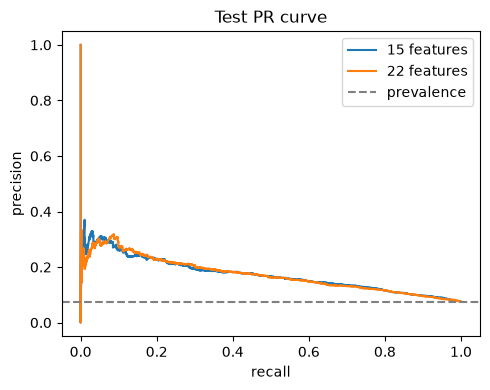

In [15]:
prec15, rec15, _ = precision_recall_curve(y_test, proba15)
prec22, rec22, _ = precision_recall_curve(y_test, proba22)

plt.figure(figsize=(5, 4))
plt.plot(rec15, prec15, label="15 features")
plt.plot(rec22, prec22, label="22 features")
plt.axhline(y_test.mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_engineered_pr_curve.png", dpi=100)
plt.show()

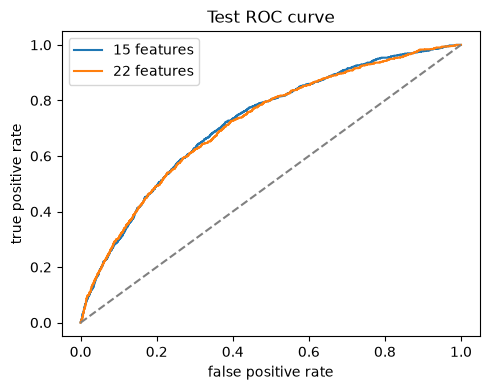

In [16]:
fpr15, tpr15, _ = roc_curve(y_test, proba15)
fpr22, tpr22, _ = roc_curve(y_test, proba22)

plt.figure(figsize=(5, 4))
plt.plot(fpr15, tpr15, label="15 features")
plt.plot(fpr22, tpr22, label="22 features")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_engineered_roc_curve.png", dpi=100)
plt.show()

## Coefficients (22-feature model)

Standardized features, so magnitudes are roughly comparable, but several of these features are directly derived from each other (a rate and the counts it came from), so individual coefficients shouldn't be read as independent effects.

In [17]:
coefs = pipe22.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": FEATURES_22, "coefficient": coefs})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient,abs_coefficient
0,prev_non_pass,-0.513895,0.513895
1,prior_730d_infractions_per_inspection,0.404323,0.404323
2,prior_730d_total_infractions,0.223872,0.223872
3,prior_365d_total_infractions,-0.211031,0.211031
4,prev_total_infractions,0.182747,0.182747
5,prior_365d_infractions_per_inspection,0.159564,0.159564
6,consecutive_passes,-0.147557,0.147557
7,prior_365d_n_non_pass,0.113805,0.113805
8,infraction_change_365_vs_730,0.109907,0.109907
9,prior_365d_n_inspections,0.109709,0.109709


`prev_non_pass` and `prior_730d_infractions_per_inspection` have the largest coefficients, with the engineered rate feature actually outranking several of the original count features. `consecutive_passes` and `infraction_change_365_vs_730` also show up around the middle of the ranking, so the new features aren't dead weight individually, they just don't add enough net signal to move the aggregate test metrics.

## Save results

In [18]:
results = pd.DataFrame([
    {"model": "logistic_engineered_22feat", "feature_set": "15 existing + 7 engineered longitudinal features",
     "val_pr_auc": metrics22["val_pr_auc"], "val_roc_auc": metrics22["val_roc_auc"],
     "threshold": metrics22["threshold"],
     "test_pr_auc": metrics22["test_pr_auc"], "test_roc_auc": metrics22["test_roc_auc"],
     "test_precision": metrics22["test_precision"], "test_recall": metrics22["test_recall"],
     "test_f1": metrics22["test_f1"], "test_accuracy": metrics22["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results.to_csv("../outputs/logistic_engineered_results.csv", index=False)
coef_df.to_csv("../outputs/logistic_engineered_coefficients.csv", index=False)
print("saved outputs/logistic_engineered_results.csv")
print("saved outputs/logistic_engineered_coefficients.csv")

saved outputs/logistic_engineered_results.csv
saved outputs/logistic_engineered_coefficients.csv


## Interpretation

Adding the seven engineered recency, streak, rate, and trend features to the 15-feature Logistic Regression did not produce a meaningful improvement (test PR-AUC 0.173 vs 0.172, ROC-AUC 0.720 vs 0.717, F1 slightly lower). Most of the useful information in these features overlaps with the count-based features already in the model, a linear model doesn't seem to need the extra normalized representations to extract that signal. This is a valid negative result for this specific model and feature set, it doesn't mean recency or rate framing is useless in general, just that it didn't help Logistic Regression here.